In [58]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model selection
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    RandomizedSearchCV,
    RepeatedStratifiedKFold
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import classification_report, confusion_matrix


## Importing the dataset

In [59]:
df = pd.read_csv("../dataset/titanic.csv")

## Dataset first view

In [60]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Visualizations and Diagrams

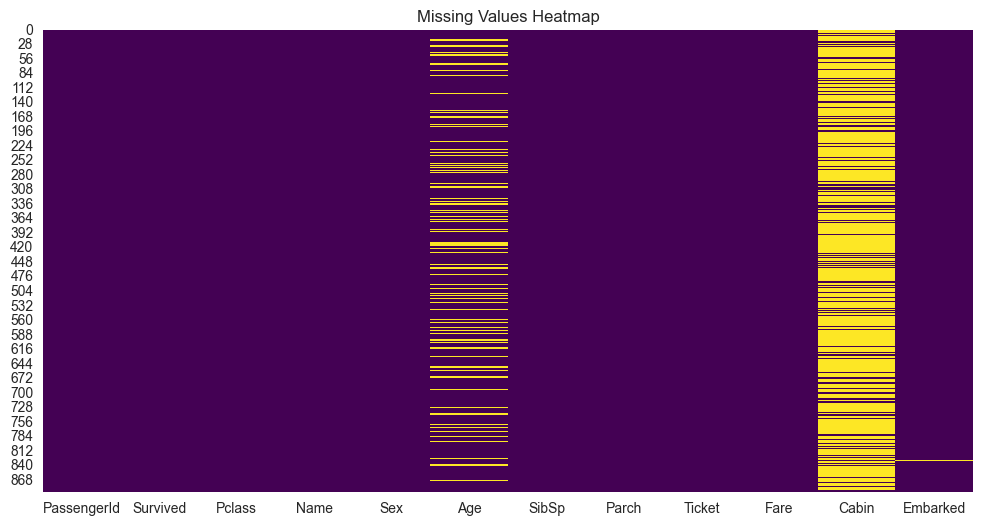

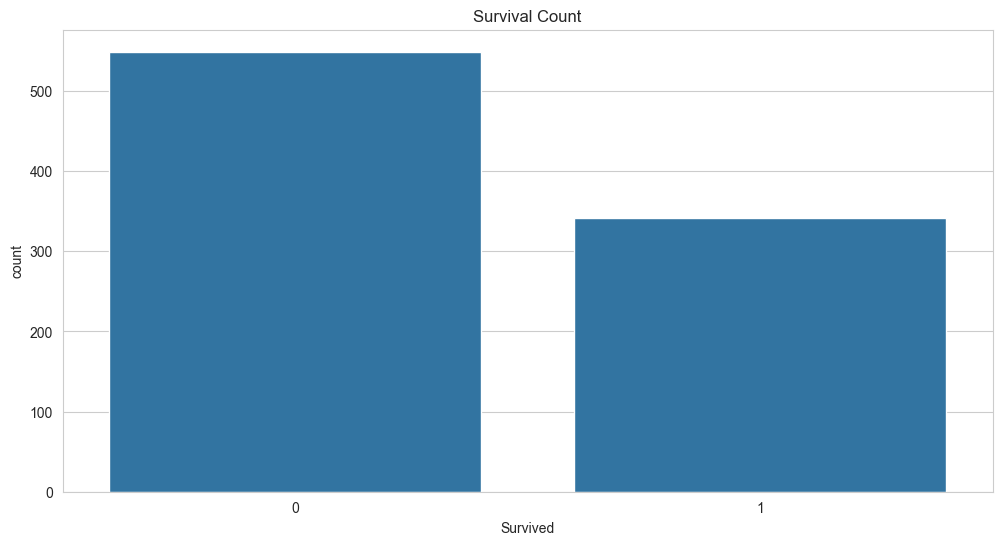

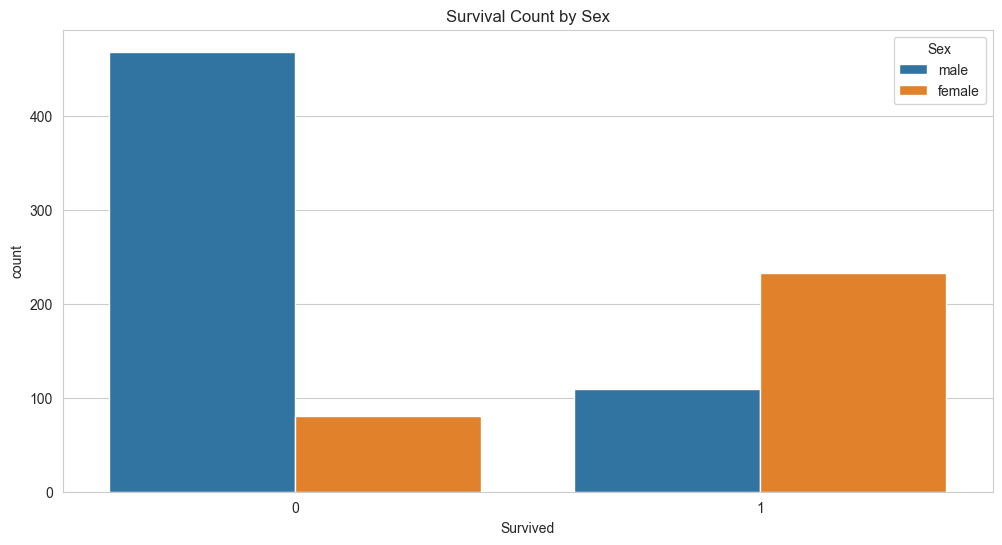

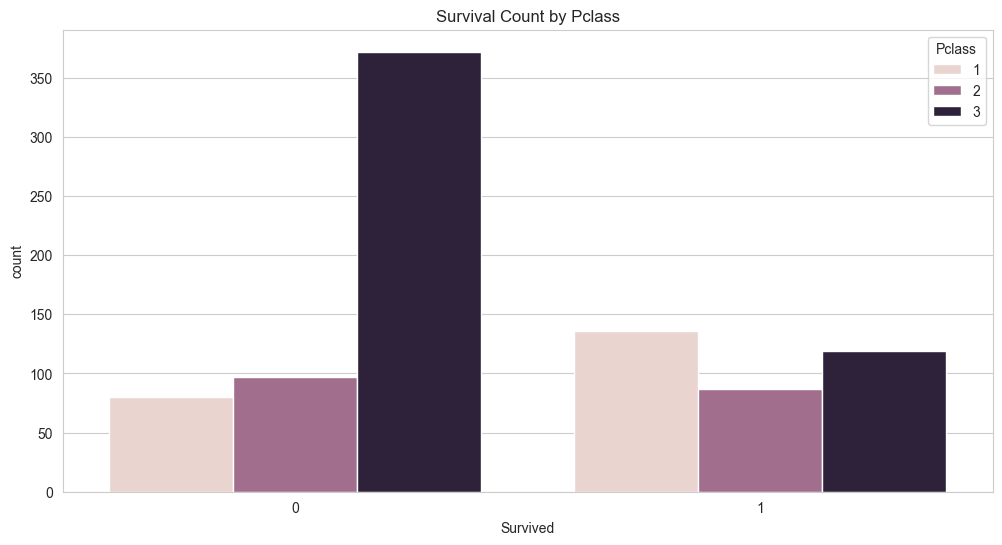

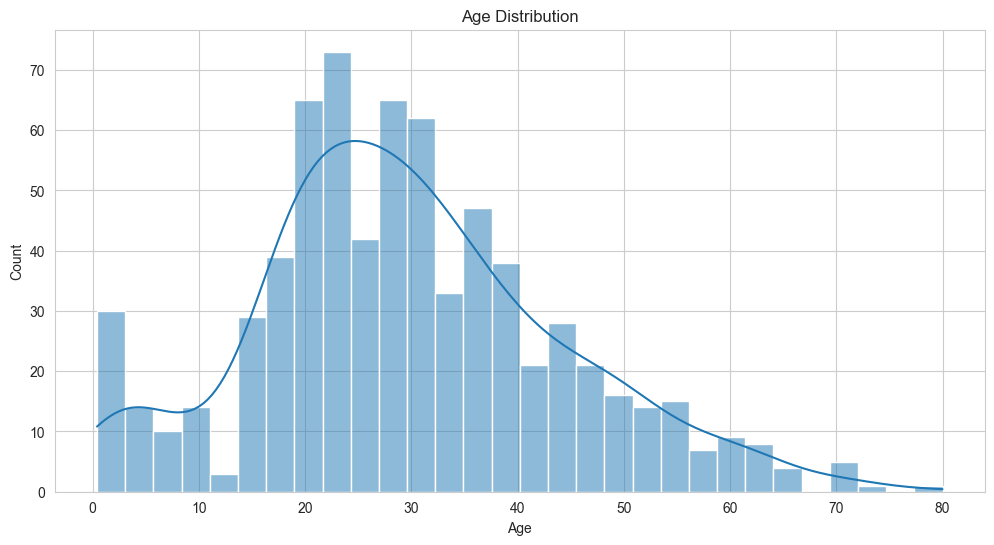

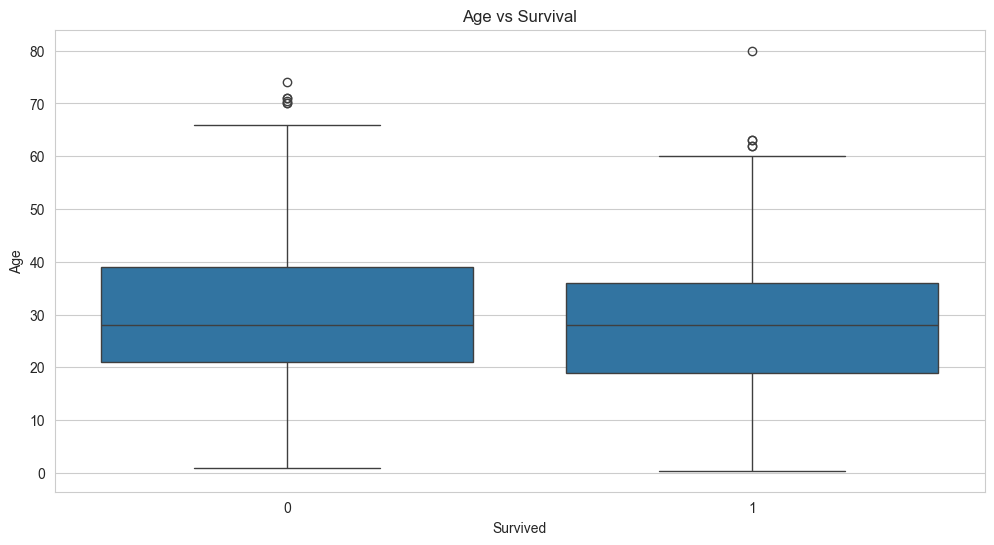

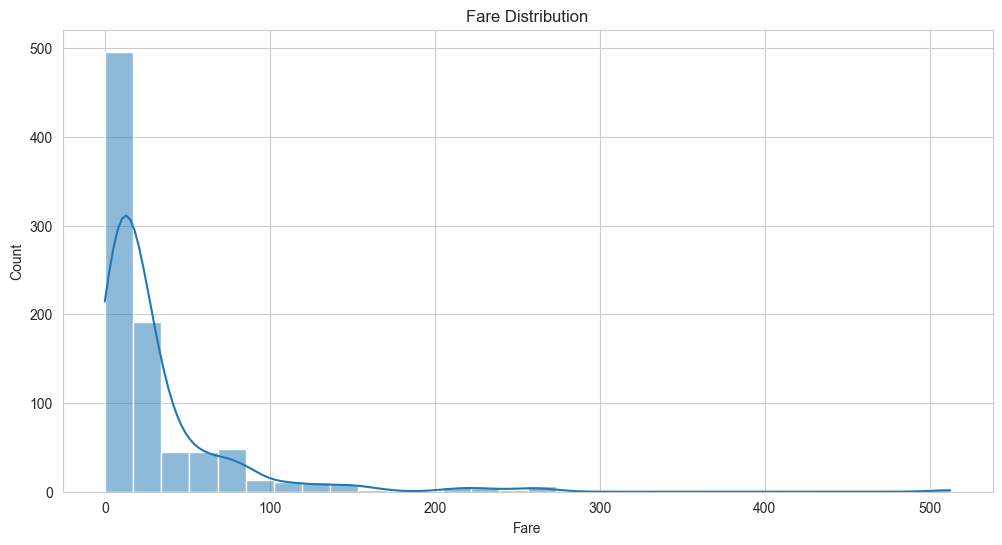

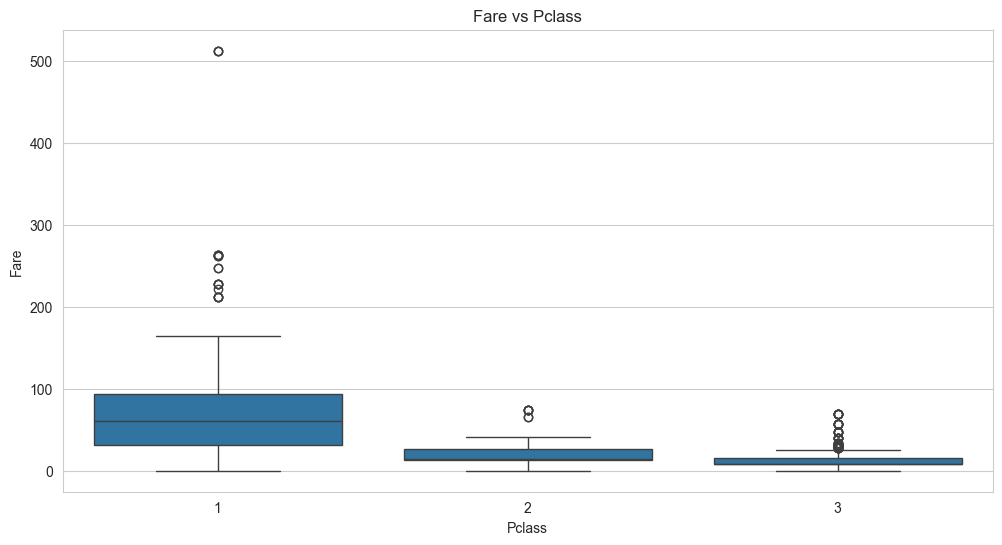

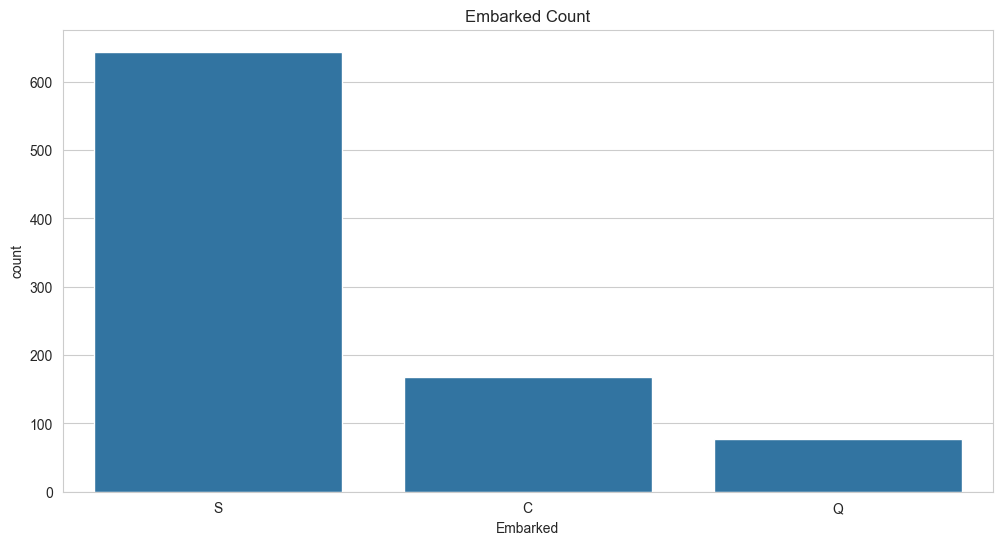

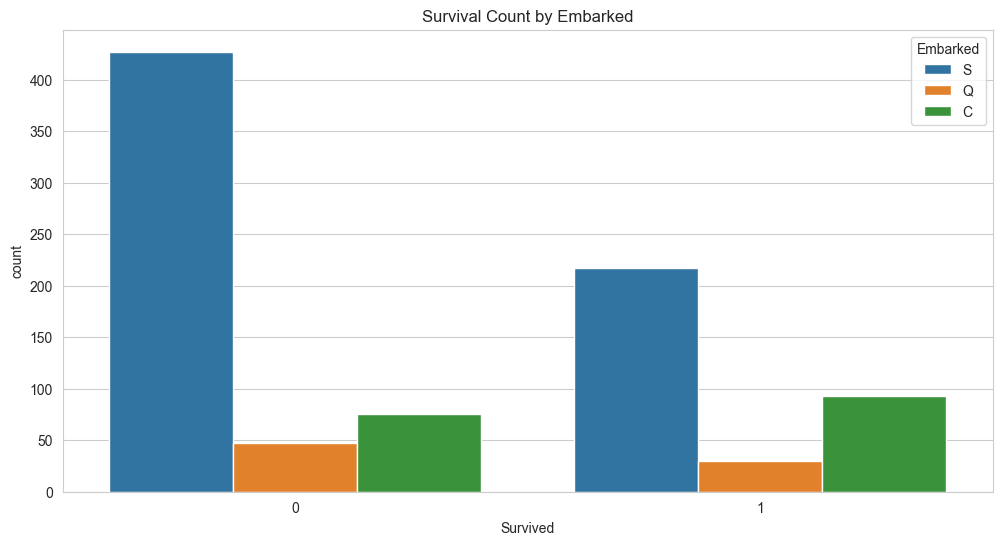

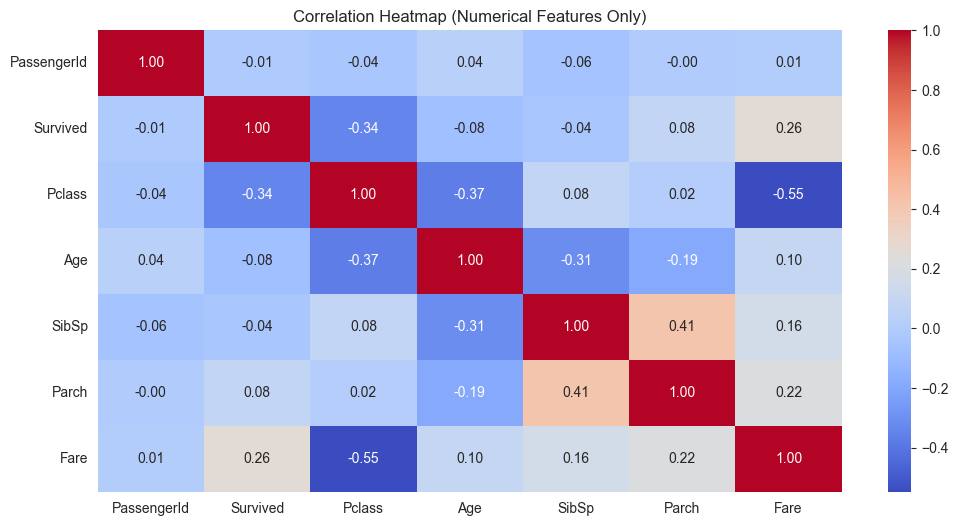

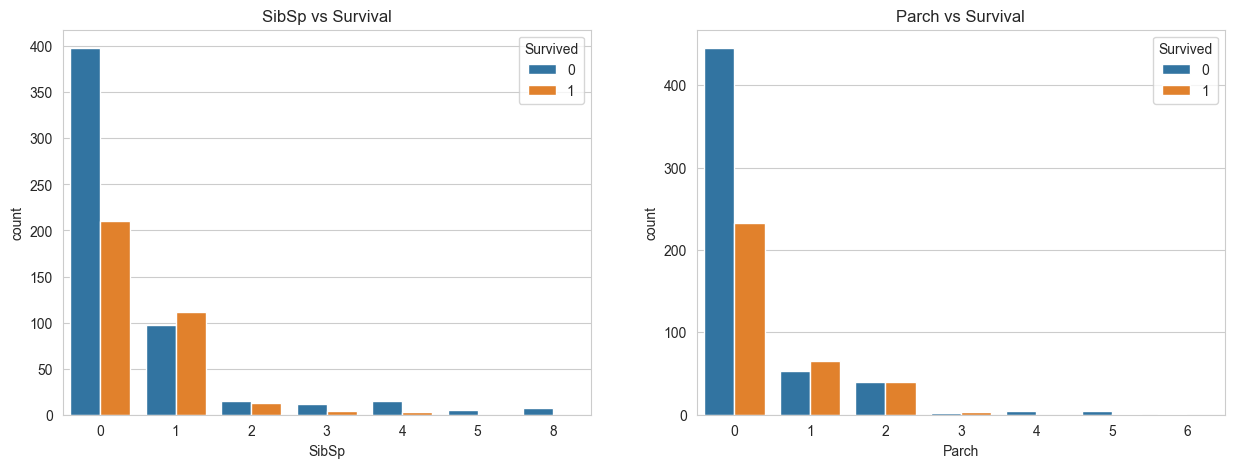

In [61]:

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

# 1️⃣ Missing Values Heatmap
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

# 2️⃣ Survival Count
sns.countplot(data=df, x='Survived')
plt.title("Survival Count")
plt.show()

# 3️⃣ Survival by Sex
sns.countplot(data=df, x='Survived', hue='Sex')
plt.title("Survival Count by Sex")
plt.show()

# 4️⃣ Survival by Pclass
sns.countplot(data=df, x='Survived', hue='Pclass')
plt.title("Survival Count by Pclass")
plt.show()

# 5️⃣ Age Distribution
sns.histplot(df['Age'], bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

# 6️⃣ Age vs Survival (Boxplot)
sns.boxplot(data=df, x='Survived', y='Age')
plt.title("Age vs Survival")
plt.show()

# 7️⃣ Fare Distribution
sns.histplot(df['Fare'], bins=30, kde=True)
plt.title("Fare Distribution")
plt.show()

# 8️⃣ Fare vs Pclass (Boxplot)
sns.boxplot(data=df, x='Pclass', y='Fare')
plt.title("Fare vs Pclass")
plt.show()

# 9️⃣ Count of Embarked
sns.countplot(data=df, x='Embarked')
plt.title("Embarked Count")
plt.show()

# 🔟 Survival by Embarked
sns.countplot(data=df, x='Survived', hue='Embarked')
plt.title("Survival Count by Embarked")
plt.show()

# 1️⃣1️⃣ Correlation Heatmap (Numerical Only)
numerical_cols = df.select_dtypes(include=['int64','float64'])
sns.heatmap(numerical_cols.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features Only)")
plt.show()

# 1️⃣2️⃣ SibSp and Parch vs Survival
fig, axes = plt.subplots(1,2, figsize=(15,5))
sns.countplot(data=df, x='SibSp', hue='Survived', ax=axes[0])
axes[0].set_title("SibSp vs Survival")
sns.countplot(data=df, x='Parch', hue='Survived', ax=axes[1])
axes[1].set_title("Parch vs Survival")
plt.show()


## Understanding the data

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [63]:
df.shape

(891, 12)

## Missing Values

In [64]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Filling the Missing values

In [65]:
## seeing the values distribution in each column

df[['Age','Cabin','Embarked']].isnull().mean()*100

Age         19.865320
Cabin       77.104377
Embarked     0.224467
dtype: float64

In [66]:
print(df['Age'].describe())
print("*" * 50)
print(df['Cabin'].value_counts().head())
print("*" * 50)
print(df['Embarked'].value_counts())




count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64
**************************************************
Cabin
G6             4
C23 C25 C27    4
B96 B98        4
F2             3
D              3
Name: count, dtype: int64
**************************************************
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [67]:
# Output Explanation and Purpose:

# 1. Embarked value counts show that most passengers boarded at 'S' (Southampton).
#    We do this to identify the most common embarkation point, which is useful for filling missing 'Embarked' values with the mode.

# 2. Age descriptive stats show summary like count (714 non-missing), mean (~29.7), median (28), and range (0.42 to 80).
#    We do this to understand the distribution of 'Age' and decide whether to fill missing ages with mean or median.

# 3. Cabin value counts reveal the most common cabin identifiers (e.g., 'G6', 'C23 C25 C27').
#    Since many cabins are missing, we do this to find patterns and consider extracting deck letters as a feature or filling missing cabins with 'Unknown'.


In [68]:
## fill the missing values 

df['Age']=df['Age'].fillna(df['Age'].median())
df['Embarked']=df['Embarked'].fillna(df['Embarked'].mode()[0])
df['Cabin']=df['Cabin'].fillna('Unknown')

## Duplicates

In [69]:
duplicates=df.duplicated().sum()
print("Number of duplicate rows :",duplicates)

Number of duplicate rows : 0


## Counting no of rows and columns

In [70]:
## Dataset row and column count
print("Number of rows :"  ,df.shape[0])
print("Number of columns are :"  ,df.shape[1])

Number of rows : 891
Number of columns are : 12


 # Percentage of nulls

In [71]:
df.isnull().mean() * 100           # Percentage of nulls

PassengerId    0.0
Survived       0.0
Pclass         0.0
Name           0.0
Sex            0.0
Age            0.0
SibSp          0.0
Parch          0.0
Ticket         0.0
Fare           0.0
Cabin          0.0
Embarked       0.0
dtype: float64

In [72]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [73]:
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,891.000000,891.000000,891.000000,891,891.000000,891,891
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,148,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,Unknown,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,687,646
mean,446.000000,0.383838,2.308642,NaN,NaN,29.361582,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,13.019697,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,22.000000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,35.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


In [74]:
for i in df.columns:
    print("number of unique values i ",i, "is",df[i].nunique())

number of unique values i  PassengerId is 891
number of unique values i  Survived is 2
number of unique values i  Pclass is 3
number of unique values i  Name is 891
number of unique values i  Sex is 2
number of unique values i  Age is 88
number of unique values i  SibSp is 7
number of unique values i  Parch is 7
number of unique values i  Ticket is 681
number of unique values i  Fare is 248
number of unique values i  Cabin is 148
number of unique values i  Embarked is 3


In [75]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


## Indentify the categorical columns

In [76]:
categorical_cols= df.select_dtypes(include=['object','category']).columns
print(categorical_cols)

Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')



## Indentify the numerical columns

In [77]:
numerical_cols=df.select_dtypes(include=['number']).columns
print(numerical_cols)

Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


In [78]:
df['Cabin'].value_counts().unique()
df['Cabin'].value_counts()

Cabin
Unknown        687
G6               4
C23 C25 C27      4
B96 B98          4
F2               3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

In [79]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,Unknown,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,Unknown,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,Unknown,S


## Removing unnecessary columns since they do not contribute much to the prediction task

In [80]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],inplace=True)

In [81]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [82]:
#Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')  are categorical columns
# out of which name, Ticket and Cabin are not useful for prediction so we  dropped  them
#remaining categorical columns are embarked and sex
#since both are nominal categorical columns we will do one hot encoding for them

In [83]:
# | Column type              | Best encoding    | Notes                                     |
# | ------------------------ | ---------------- | ----------------------------------------- |
# | Nominal, few categories  | One-Hot          | Works for all models                      |
# | Nominal, many categories | Frequency/Target | Avoid exploding columns                   |
# | Nominal for trees        | Label Encoding   | Efficient for trees, order doesn’t matter |


In [84]:
## Encoding the categorical columns

In [85]:

df = pd.get_dummies(data=df, columns=['Sex', 'Embarked'], drop_first=True)

In [86]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


## Feature and Target separation

In [87]:
X=df.drop(columns=['Survived'])
y=df['Survived']

In [88]:
print(X.shape)
print(y.shape)

(891, 8)
(891,)


## Train test split

In [89]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [90]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(623, 8)
(268, 8)
(623,)
(268,)


In [91]:
X_train

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
445,1,4.0,0,2,81.8583,True,False,True
650,3,28.0,0,0,7.8958,True,False,True
172,3,1.0,1,1,11.1333,False,False,True
450,2,36.0,1,2,27.7500,True,False,True
314,2,43.0,1,1,26.2500,True,False,True
...,...,...,...,...,...,...,...,...
106,3,21.0,0,0,7.6500,False,False,True
270,1,28.0,0,0,31.0000,True,False,True
860,3,41.0,2,0,14.1083,True,False,True
435,1,14.0,1,2,120.0000,False,False,True


## Feature Scaling

In [92]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train= scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)

## Feature Engineering

In [93]:
# #SibSp (siblings/spouses aboard) and Parch (parents/children aboard) can be combined into a single feature to capture family context
df['family_size'] = df['SibSp'] + df['Parch'] + 1
df.drop(columns=['SibSp','Parch'],inplace=True)

## MODEL Implementation

In [94]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

def evaluate_model(model, X_train, X_test, y_train, y_test):
    # 1️⃣ Fit the model
    model.fit(X_train, y_train)

    # 2️⃣ Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # 3️⃣ Confusion matrices
    confusion_matrix_train = confusion_matrix(y_train, y_train_pred)
    confusion_matrix_test = confusion_matrix(y_test, y_test_pred)

    # 4️⃣ Plot confusion matrices
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))

    sns.heatmap(confusion_matrix_train, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                ax=ax[0])
    ax[0].set_xlabel("Predicted Label")
    ax[0].set_ylabel("True Label")
    ax[0].set_title("Train Confusion Matrix")

    sns.heatmap(confusion_matrix_test, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'],
                ax=ax[1])
    ax[1].set_xlabel("Predicted Label")
    ax[1].set_ylabel("True Label")
    ax[1].set_title("Test Confusion Matrix")

    plt.tight_layout()
    plt.show()

    # 5️⃣ Classification reports
    classification_report_train = classification_report(y_train, y_train_pred, output_dict=True)
    classification_report_test = classification_report(y_test, y_test_pred, output_dict=True)

    # 6️⃣ Convert to DataFrame for better readability
    train_report_df = pd.DataFrame(classification_report_train).T
    test_report_df = pd.DataFrame(classification_report_test).T

    print(f"\n{model} Train Classification Report:")
    print(train_report_df.to_markdown())

    print(f"\n{model} Test Classification Report:")
    print(test_report_df.to_markdown())


    # Extract the metrics
    precision_train = classification_report_train['weighted avg']['precision']
    precision_test  = classification_report_test['weighted avg']['precision']

    recall_train = classification_report_train['weighted avg']['recall']
    recall_test  = classification_report_test['weighted avg']['recall']

    f1_score_train = classification_report_train['weighted avg']['f1-score']
    f1_score_test  = classification_report_test['weighted avg']['f1-score']

    accuracy_train = classification_report_train['accuracy']
    accuracy_test  = classification_report_test['accuracy']

    performance_metrics = [precision_train, precision_test,
                           recall_train, recall_test,
                           f1_score_train, f1_score_test,
                           accuracy_train, accuracy_test]

    return performance_metrics


In [95]:
scores= pd.DataFrame(index=['Train_Precision', 'Test_Precision',
                            'Train_Recall', 'Test_Recall',
                            'Train_F1_Score', 'Test_F1_Score',
                            'Train_Accuracy', 'Test_Accuracy'])

scores

""
Train_Precision
Test_Precision
Train_Recall
Test_Recall
Train_F1_Score
Test_F1_Score
Train_Accuracy
Test_Accuracy


In [96]:
## Model 1 : Logistic Regression
logistic_regression_model = LogisticRegression(max_iter=200,fit_intercept=True)

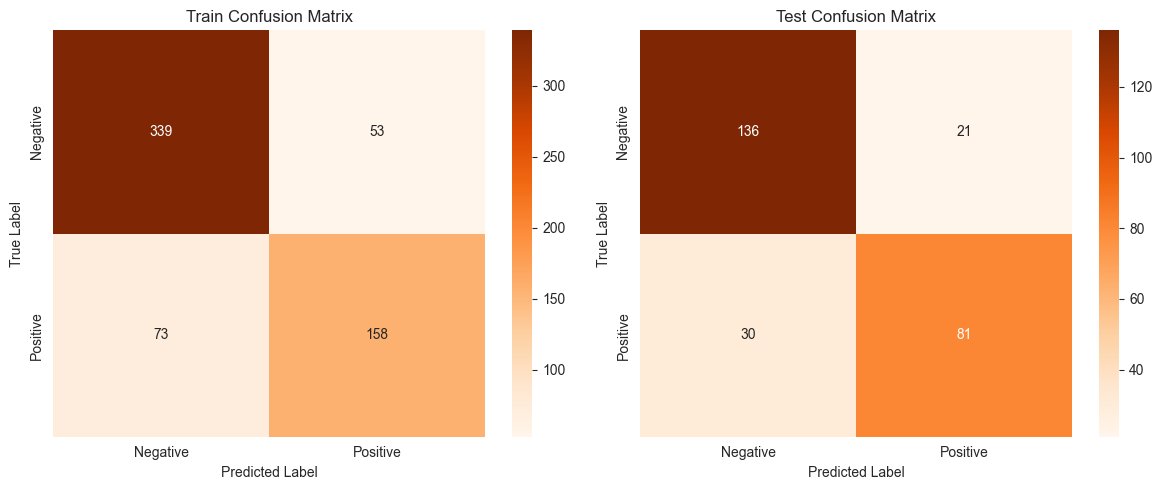


LogisticRegression(max_iter=200) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.822816 | 0.864796 |   0.843284 | 392        |
| 1            |    0.748815 | 0.683983 |   0.714932 | 231        |
| accuracy     |    0.797753 | 0.797753 |   0.797753 |   0.797753 |
| macro avg    |    0.785815 | 0.774389 |   0.779108 | 623        |
| weighted avg |    0.795377 | 0.797753 |   0.795693 | 623        |

LogisticRegression(max_iter=200) Test Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.819277 | 0.866242 |   0.842105 | 157        |
| 1            |    0.794118 | 0.72973  |   0.760563 | 111        |
| accuracy     |    0.809701 | 0.809701 |   0.809701 |   0.809701 |
| macro avg    |    0.806697 | 0.797986 |   0.801334 | 268 

In [97]:
## Explaining the model using the evaluate_model function

logistic_regression_scores= evaluate_model(logistic_regression_model, X_train, X_test, y_train, y_test)

## Cross validation and hyperparameter tuning on the Logisitic Regression Model

In [98]:

# Define parameter grid
param_grid = [
    # For l1 penalty
    {
        'C': [100, 10, 1, 0.1, 0.01, 0.001, 0.0001],
        'penalty': ['l1'],
        'solver': ['liblinear', 'saga']
    },
    # For l2 penalty
    {
        'C': [100, 10, 1, 0.1, 0.01, 0.001, 0.0001],
        'penalty': ['l2'],
        'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga']
    }
]

# Logistic Regression model with increased max_iter and random_state for reproducibility
logistic_regression_model = LogisticRegression(max_iter=1000, fit_intercept=True, random_state=42, class_weight='balanced')

# Repeated Stratified K-Fold
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# GridSearchCV
grid_search = GridSearchCV(logistic_regression_model, param_grid, cv=rskf, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Get best results
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Hyperparameters:", best_params)
print("Best Cross-Validation Score:", best_score)

# Final model with best hyperparameters
best_logistic_model = grid_search.best_estimator_


Best Hyperparameters: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
Best Cross-Validation Score: 0.7849032258064518


## Train the model with best hyperparameters

In [99]:
## Initialize the model with best parameters
logistic_regression_model2 = LogisticRegression(
    C=best_params['C'],
    penalty=best_params['penalty'],
    solver=best_params['solver'],
    max_iter=10000, #inreasing the max-iters to make sure it reaches convergence
    random_state=0
)

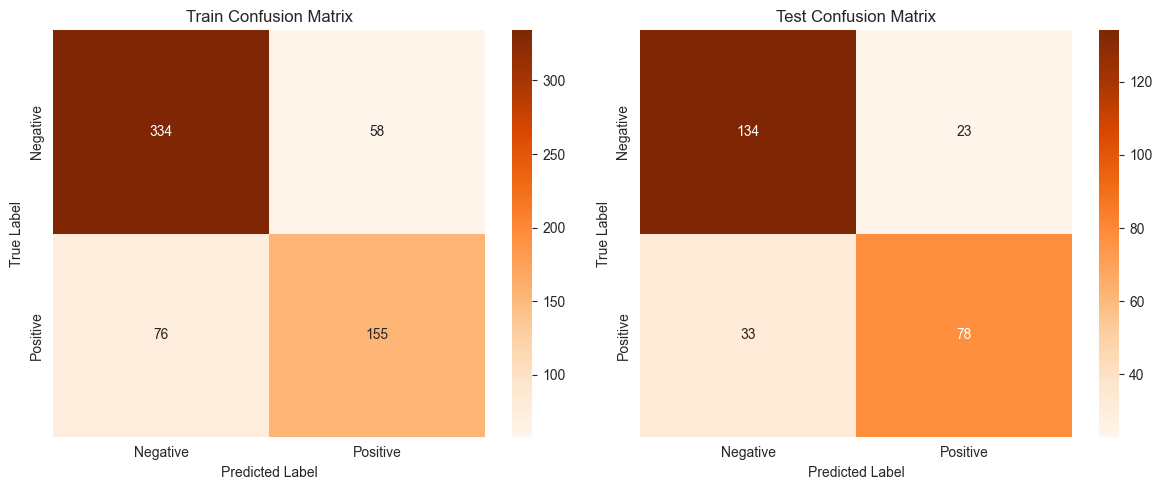


LogisticRegression(C=0.01, max_iter=10000, penalty='l1', random_state=0,
                   solver='liblinear') Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.814634 | 0.852041 |   0.832918 | 392        |
| 1            |    0.7277   | 0.670996 |   0.698198 | 231        |
| accuracy     |    0.784912 | 0.784912 |   0.784912 |   0.784912 |
| macro avg    |    0.771167 | 0.761518 |   0.765558 | 623        |
| weighted avg |    0.7824   | 0.784912 |   0.782966 | 623        |

LogisticRegression(C=0.01, max_iter=10000, penalty='l1', random_state=0,
                   solver='liblinear') Test Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.802395 | 0.853503 |   0.82716  | 157        |
| 1            |    0.772277 | 0.7027

In [100]:
## Explaining the model using the evaluate_model function

logistic_regression_scores2= evaluate_model(logistic_regression_model2, X_train, X_test, y_train, y_test)

In [101]:
scores['Logistic_Regression']=logistic_regression_scores2
scores

,Logistic_Regression
Train_Precision,0.782400
Test_Precision,0.789921
Train_Recall,0.784912
Test_Recall,0.791045
Train_F1_Score,0.782966
Test_F1_Score,0.789341
Train_Accuracy,0.784912
Test_Accuracy,0.791045


## Model 2- Decision Tree

In [102]:
decision_tree_model= DecisionTreeClassifier(random_state=42)

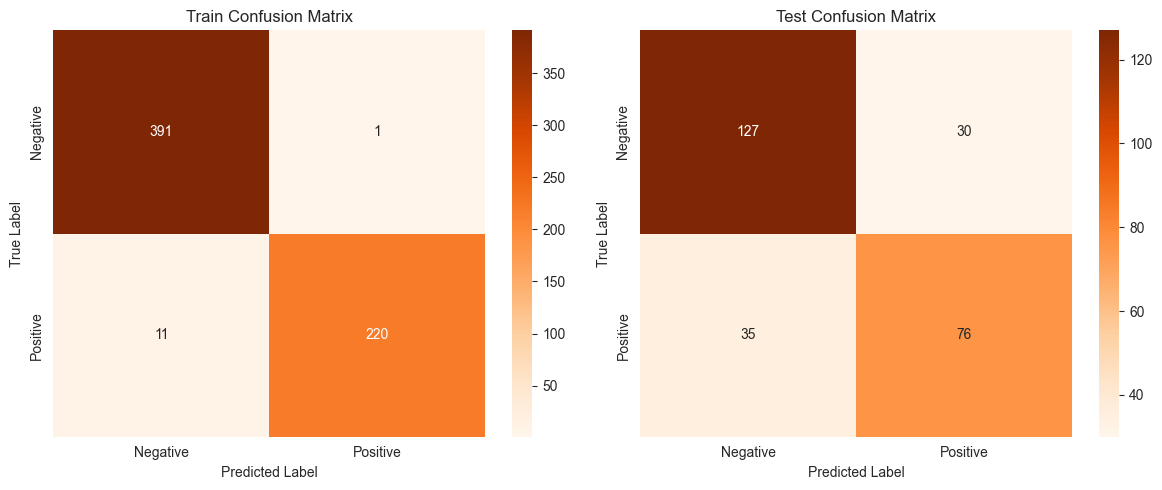


DecisionTreeClassifier(random_state=42) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.972637 | 0.997449 |   0.984887 | 392        |
| 1            |    0.995475 | 0.952381 |   0.973451 | 231        |
| accuracy     |    0.980738 | 0.980738 |   0.980738 |   0.980738 |
| macro avg    |    0.984056 | 0.974915 |   0.979169 | 623        |
| weighted avg |    0.981105 | 0.980738 |   0.980647 | 623        |

DecisionTreeClassifier(random_state=42) Test Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.783951 | 0.808917 |   0.796238 | 157        |
| 1            |    0.716981 | 0.684685 |   0.700461 | 111        |
| accuracy     |    0.757463 | 0.757463 |   0.757463 |   0.757463 |
| macro avg    |    0.750466 | 0.746801 |   0

In [103]:
decision_tree_model_scores= evaluate_model(decision_tree_model,X_train,X_test,y_train,y_test)

## Cross validation and hyperparameter tuning on the Decision Tree Model

In [104]:
params_grid ={
    'max_depth':[3,4,5,6,7,8],
    'min_samples_split':np.arange(2,10),
    'min_samples_leaf':np.arange(1,6)
}

decision_tree_model= DecisionTreeClassifier(random_state=42)

rskf=RepeatedStratifiedKFold(n_splits=5,n_repeats=3,random_state=42)

#intializing the gridsearchcv
grid_search= GridSearchCV(decision_tree_model,params_grid,cv=rskf,n_jobs=-1)
grid_search.fit(X_train,y_train)

best_params=grid_search.best_params_
best_score=grid_search.best_score_

print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'max_depth': 3, 'min_samples_leaf': np.int64(3), 'min_samples_split': np.int64(2)}


In [105]:
## train the model with best parameters
decision_tree_model2=DecisionTreeClassifier(
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    min_samples_leaf=best_params['min_samples_leaf'],
    random_state=42
)

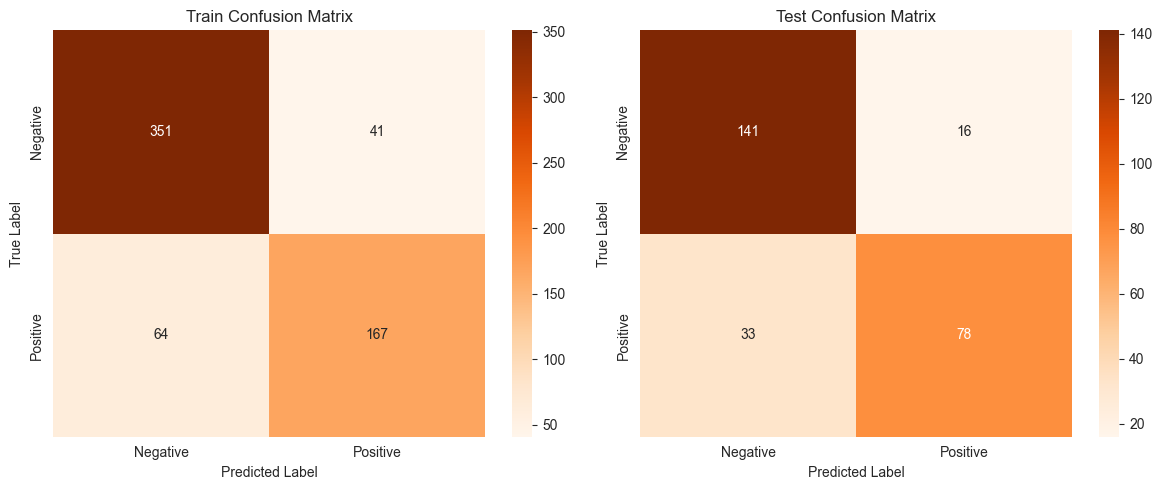


DecisionTreeClassifier(max_depth=3, min_samples_leaf=np.int64(3),
                       min_samples_split=np.int64(2), random_state=42) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.845783 | 0.895408 |   0.869888 | 392        |
| 1            |    0.802885 | 0.722944 |   0.76082  | 231        |
| accuracy     |    0.831461 | 0.831461 |   0.831461 |   0.831461 |
| macro avg    |    0.824334 | 0.809176 |   0.815354 | 623        |
| weighted avg |    0.829877 | 0.831461 |   0.829447 | 623        |

DecisionTreeClassifier(max_depth=3, min_samples_leaf=np.int64(3),
                       min_samples_split=np.int64(2), random_state=42) Test Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.810345 | 0.898089 |   0.851964 | 

In [106]:
decision_tree_model_scores2= evaluate_model(decision_tree_model2,X_train,X_test,y_train,y_test)

In [107]:
scores['Decision_Tree']=decision_tree_model_scores2
scores

,Logistic_Regression,Decision_Tree
Train_Precision,0.782400,0.829877
Test_Precision,0.789921,0.818397
Train_Recall,0.784912,0.831461
Test_Recall,0.791045,0.817164
Train_F1_Score,0.782966,0.829447
Test_F1_Score,0.789341,0.814278
Train_Accuracy,0.784912,0.831461
Test_Accuracy,0.791045,0.817164


##  Model 3- Random Forest

In [108]:
random_forest_model= RandomForestClassifier(random_state=42)

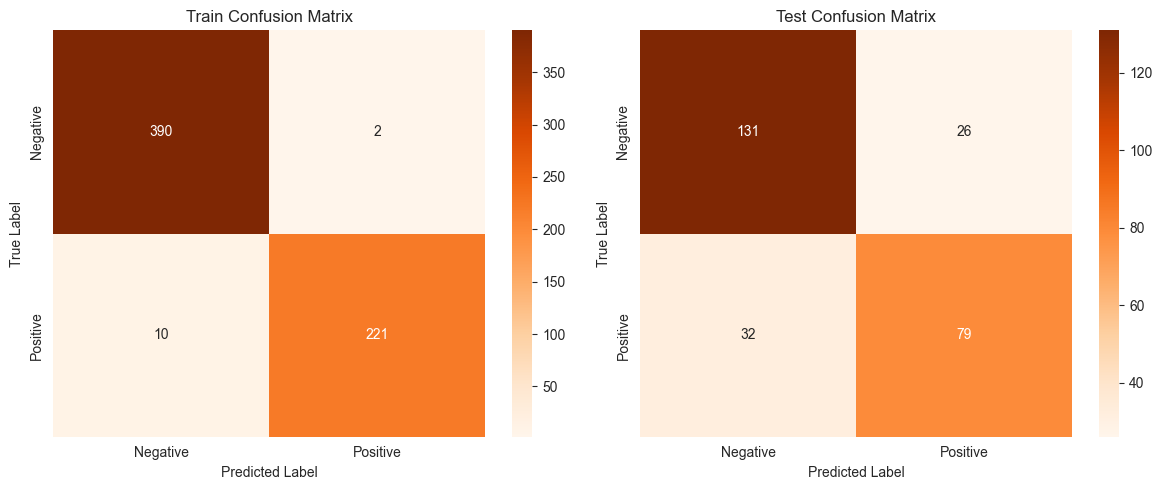


RandomForestClassifier(random_state=42) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.975    | 0.994898 |   0.984848 | 392        |
| 1            |    0.991031 | 0.95671  |   0.973568 | 231        |
| accuracy     |    0.980738 | 0.980738 |   0.980738 |   0.980738 |
| macro avg    |    0.983016 | 0.975804 |   0.979208 | 623        |
| weighted avg |    0.980944 | 0.980738 |   0.980666 | 623        |

RandomForestClassifier(random_state=42) Test Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.803681 | 0.834395 |   0.81875  | 157        |
| 1            |    0.752381 | 0.711712 |   0.731481 | 111        |
| accuracy     |    0.783582 | 0.783582 |   0.783582 |   0.783582 |
| macro avg    |    0.778031 | 0.773053 |   0

In [109]:
random_forest_model_scores= evaluate_model(random_forest_model,X_train,X_test,y_train,y_test)

## Cross validation and hyperparameter tuning on the Random Forest Model

In [110]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, RepeatedStratifiedKFold

# only updated min_samples_split and added min_samples_leaf
params_grid = {
   'n_estimators': [10,50,100,200,300],
   'max_depth': [7,8,9,10,11,12,15,20],
   'min_samples_split': [10,20,30,40,50],  # keep your change
   'min_samples_leaf': [2,4,6]             # added to reduce overfitting
}

# model
random_forest_model = RandomForestClassifier(random_state=42)

# cross-validation strategy
rskf = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# initialize the randomized search
randomized_search = RandomizedSearchCV(
    estimator=random_forest_model,
    param_distributions=params_grid,  
    cv=rskf,
    n_iter=20,               
    random_state=42,
    n_jobs=-1,
    scoring='f1'              # add scoring to focus on balanced performance
)

# fit
randomized_search.fit(X_train, y_train)

# best results
best_params = randomized_search.best_params_
best_score = randomized_search.best_score_

print("Best Hyperparameters:", best_params)
print("Best CV Score:", best_score)


Best Hyperparameters: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 8}
Best CV Score: 0.7421126196704251


In [111]:
## train the model with best parameters

random_forest_model2= RandomForestClassifier(
    n_estimators=best_params['n_estimators'],
    max_depth=best_params['max_depth'],
    min_samples_split=best_params['min_samples_split'],
    random_state=42
)

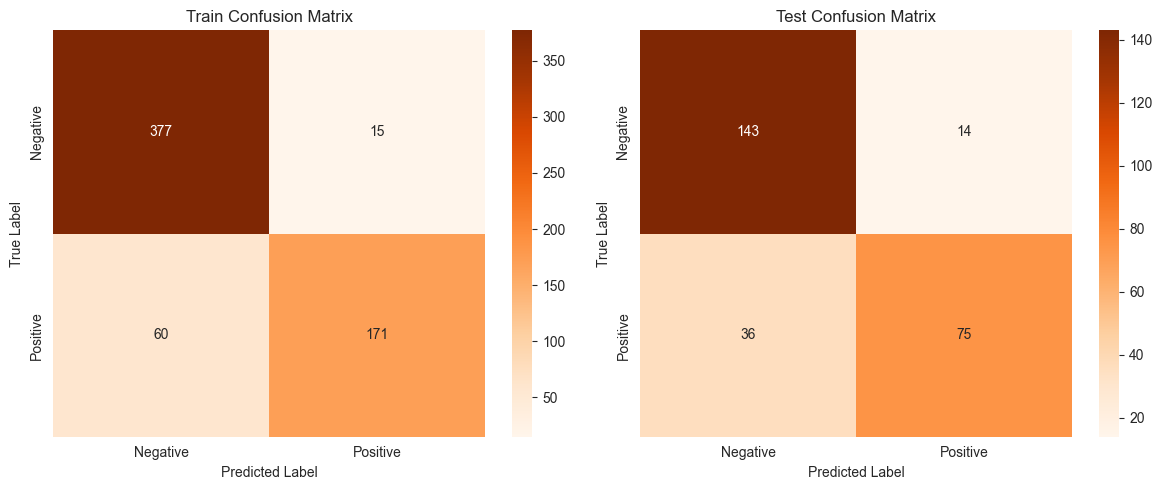


RandomForestClassifier(max_depth=8, min_samples_split=10, n_estimators=200,
                       random_state=42) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.8627   | 0.961735 |   0.90953  | 392        |
| 1            |    0.919355 | 0.74026  |   0.820144 | 231        |
| accuracy     |    0.879615 | 0.879615 |   0.879615 |   0.879615 |
| macro avg    |    0.891028 | 0.850997 |   0.864837 | 623        |
| weighted avg |    0.883707 | 0.879615 |   0.876387 | 623        |

RandomForestClassifier(max_depth=8, min_samples_split=10, n_estimators=200,
                       random_state=42) Test Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.798883 | 0.910828 |   0.85119  | 157        |
| 1            |    0.842697 

In [112]:
random_forest_model_scores2= evaluate_model(random_forest_model2,X_train,X_test,y_train,y_test)

In [113]:
scores['Random_Forest']=random_forest_model_scores2
scores

,Logistic_Regression,Decision_Tree,Random_Forest
Train_Precision,0.782400,0.829877,0.883707
Test_Precision,0.789921,0.818397,0.817030
Train_Recall,0.784912,0.831461,0.879615
Test_Recall,0.791045,0.817164,0.813433
Train_F1_Score,0.782966,0.829447,0.876387
Test_F1_Score,0.789341,0.814278,0.809279
Train_Accuracy,0.784912,0.831461,0.879615
Test_Accuracy,0.791045,0.817164,0.813433


In [114]:
## Model 4 : Support Vector Machine
svm_model= SVC(kernel='linear',random_state=42,probability=True)

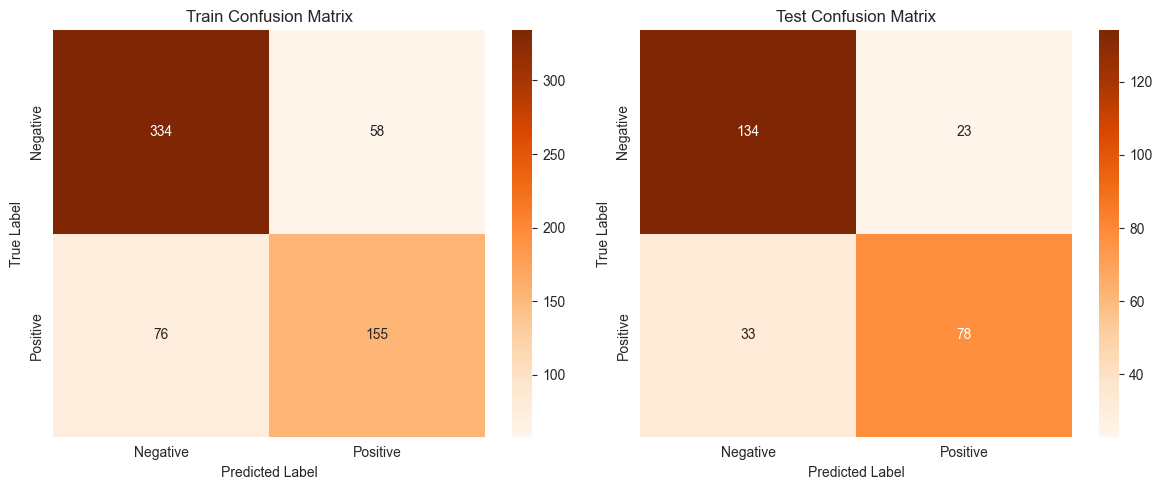


SVC(kernel='linear', probability=True, random_state=42) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.814634 | 0.852041 |   0.832918 | 392        |
| 1            |    0.7277   | 0.670996 |   0.698198 | 231        |
| accuracy     |    0.784912 | 0.784912 |   0.784912 |   0.784912 |
| macro avg    |    0.771167 | 0.761518 |   0.765558 | 623        |
| weighted avg |    0.7824   | 0.784912 |   0.782966 | 623        |

SVC(kernel='linear', probability=True, random_state=42) Test Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.802395 | 0.853503 |   0.82716  | 157        |
| 1            |    0.772277 | 0.702703 |   0.735849 | 111        |
| accuracy     |    0.791045 | 0.791045 |   0.791045 |   0.791045 |
| macro avg  

In [115]:
svm_model_scores=evaluate_model(svm_model,X_train,X_test,y_train,y_test)

## Cross validation and hyperparameter tuning for SVM

In [116]:
params_grid={
  'C':np.array([0.1,1, 10, 100]),
   'kernel':['linear','rbf'],
   'degree':np.arange(2,6,1)
}

svm_model= SVC(random_state=42,probability=False)

rsfk=RepeatedStratifiedKFold(n_splits=3,n_repeats=3,random_state=0)

#initilaize  randomized search
randomized_search= RandomizedSearchCV(
    estimator=svm_model,
    param_distributions=params_grid,
    n_iter=10,
    cv=rsfk,
    random_state=42,
    n_jobs=-1
)

randomized_search.fit(X_train,y_train)

best_params=randomized_search.best_params_
best_score=randomized_search.best_score_
print("Best Hyperparameters:", best_params)

Best Hyperparameters: {'kernel': 'rbf', 'degree': np.int64(5), 'C': np.float64(1.0)}


In [117]:
## train the model with best parameters
svm_model2= SVC(
    C=best_params['C'],
    kernel=best_params['kernel'],
    degree=best_params['degree'],
    random_state=42
)


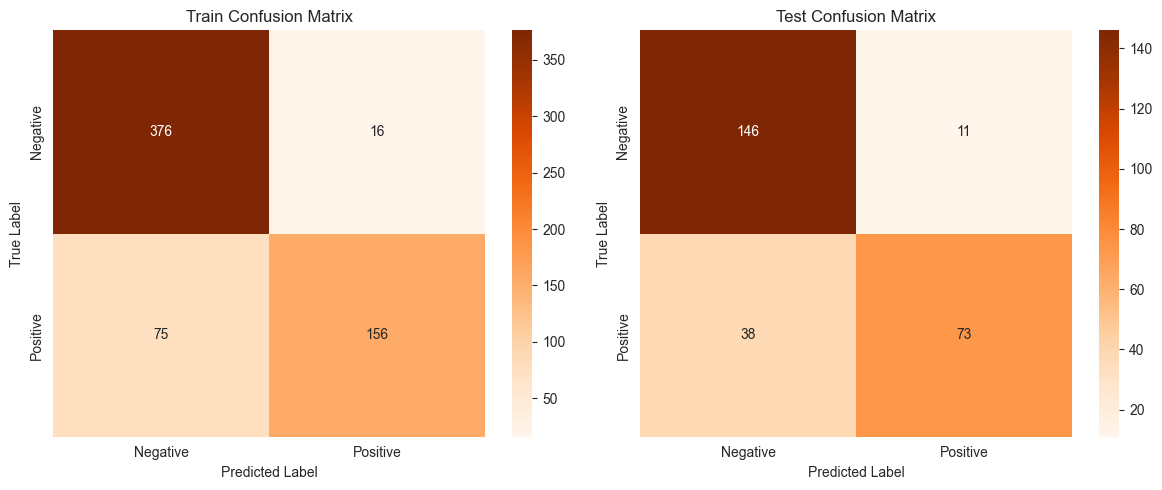


SVC(C=np.float64(1.0), degree=np.int64(5), random_state=42) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.833703 | 0.959184 |   0.892052 | 392        |
| 1            |    0.906977 | 0.675325 |   0.774194 | 231        |
| accuracy     |    0.853933 | 0.853933 |   0.853933 |   0.853933 |
| macro avg    |    0.87034  | 0.817254 |   0.833123 | 623        |
| weighted avg |    0.860872 | 0.853933 |   0.848352 | 623        |

SVC(C=np.float64(1.0), degree=np.int64(5), random_state=42) Test Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.793478 | 0.929936 |   0.856305 | 157        |
| 1            |    0.869048 | 0.657658 |   0.748718 | 111        |
| accuracy     |    0.817164 | 0.817164 |   0.817164 |   0.817164 |
| mac

In [118]:
smv_model_scores2=evaluate_model(svm_model2,X_train,X_test,y_train,y_test)

In [119]:
scores['SVM']=smv_model_scores2
scores

,Logistic_Regression,Decision_Tree,Random_Forest,SVM
Train_Precision,0.782400,0.829877,0.883707,0.860872
Test_Precision,0.789921,0.818397,0.817030,0.824778
Train_Recall,0.784912,0.831461,0.879615,0.853933
Test_Recall,0.791045,0.817164,0.813433,0.817164
Train_F1_Score,0.782966,0.829447,0.876387,0.848352
Test_F1_Score,0.789341,0.814278,0.809279,0.811745
Train_Accuracy,0.784912,0.831461,0.879615,0.853933
Test_Accuracy,0.791045,0.817164,0.813433,0.817164


## Model - 5 : Neural Network

In [120]:
from sklearn.neural_network import MLPClassifier
nn_model  = MLPClassifier(random_state=42,max_iter=1000)

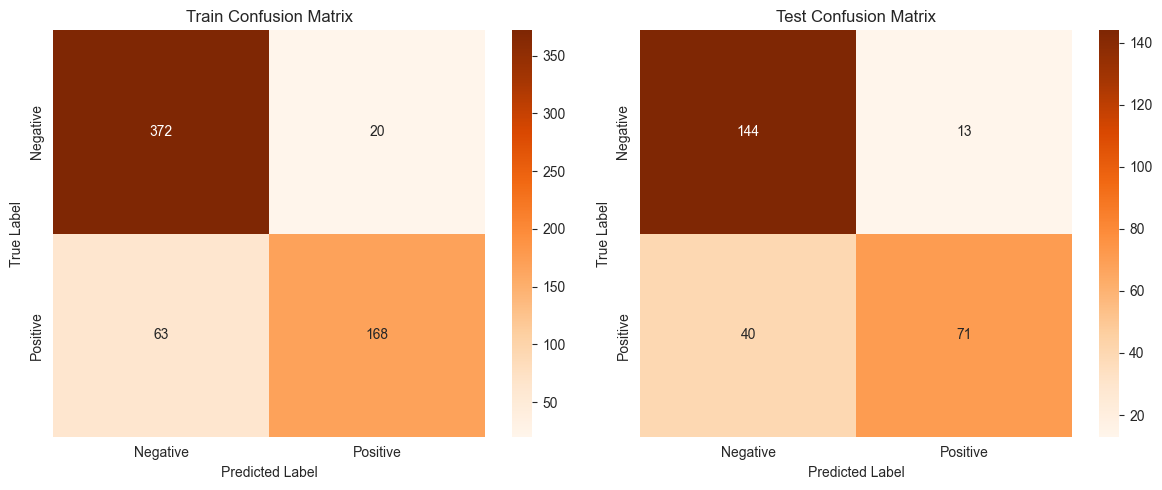


MLPClassifier(max_iter=1000, random_state=42) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.855172 | 0.94898  |   0.899637 | 392        |
| 1            |    0.893617 | 0.727273 |   0.801909 | 231        |
| accuracy     |    0.866774 | 0.866774 |   0.866774 |   0.866774 |
| macro avg    |    0.874395 | 0.838126 |   0.850773 | 623        |
| weighted avg |    0.869427 | 0.866774 |   0.863401 | 623        |

MLPClassifier(max_iter=1000, random_state=42) Test Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.782609 | 0.917197 |   0.844575 | 157        |
| 1            |    0.845238 | 0.63964  |   0.728205 | 111        |
| accuracy     |    0.802239 | 0.802239 |   0.802239 |   0.802239 |
| macro avg    |    0.813923 | 0.

In [121]:
nn_model_scores=evaluate_model(nn_model,X_train,X_test,y_train,y_test)

##  Hyperparameter tuning for Neural Network

In [122]:
params_grid={
    'hidden_layer_sizes':np.arange(10,100,10),
    'alpha': np.arange(0.0001,0.01,0.001)
}

nn_model=MLPClassifier(random_state=42,max_iter=1000)

rksf= RepeatedStratifiedKFold(n_splits=5,n_repeats=3,random_state=42)
#intializing the randomized search

randomized_search= RandomizedSearchCV(
    estimator=nn_model,
    param_distributions=params_grid,
    n_iter=10,
    cv=rskf,
    random_state=42,
    n_jobs=-1
)

randomized_search.fit(X_train,y_train)

best_params=randomized_search.best_params_
best_score=randomized_search.best_score_

print("Best Hyperparameters:", best_params)


Best Hyperparameters: {'hidden_layer_sizes': np.int64(20), 'alpha': np.float64(0.0061)}


In [123]:
## train the nn with the best parameters
nn_model2= MLPClassifier(
    hidden_layer_sizes=best_params['hidden_layer_sizes'],
    alpha=best_params['alpha'],
    random_state=42,
    max_iter=1000
)

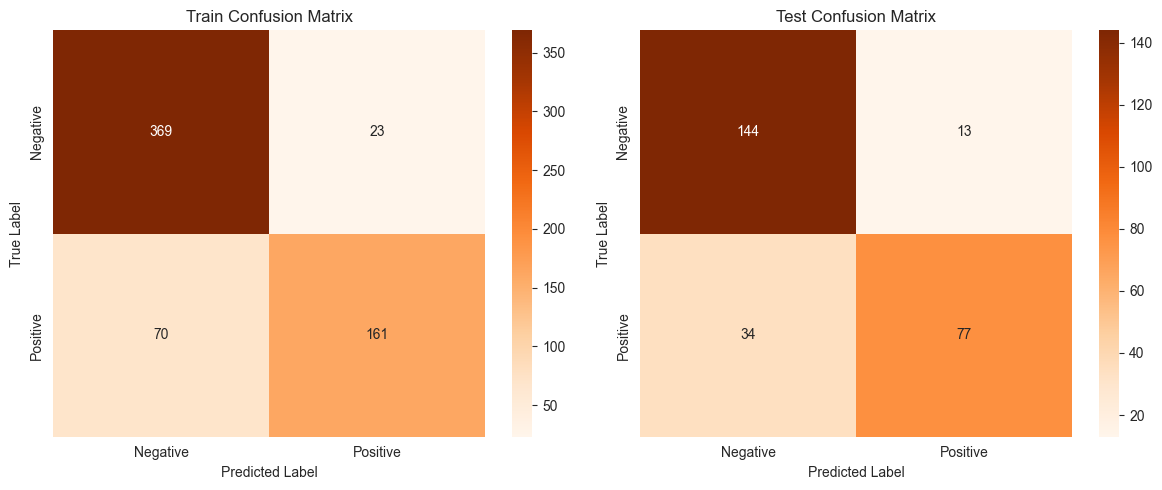


MLPClassifier(alpha=np.float64(0.0061), hidden_layer_sizes=np.int64(20),
              max_iter=1000, random_state=42) Train Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.840547 | 0.941327 |   0.888087 | 392        |
| 1            |    0.875    | 0.69697  |   0.775904 | 231        |
| accuracy     |    0.850722 | 0.850722 |   0.850722 |   0.850722 |
| macro avg    |    0.857773 | 0.819148 |   0.831995 | 623        |
| weighted avg |    0.853322 | 0.850722 |   0.846491 | 623        |

MLPClassifier(alpha=np.float64(0.0061), hidden_layer_sizes=np.int64(20),
              max_iter=1000, random_state=42) Test Classification Report:
|              |   precision |   recall |   f1-score |    support |
|:-------------|------------:|---------:|-----------:|-----------:|
| 0            |    0.808989 | 0.917197 |   0.859701 | 157        |
| 1            |    0.8

In [124]:
nn_model_scores2=evaluate_model(nn_model2,X_train,X_test,y_train,y_test)

In [125]:
scores['Neural Network']= nn_model_scores2
scores

,Logistic_Regression,Decision_Tree,Random_Forest,SVM,Neural Network
Train_Precision,0.782400,0.829877,0.883707,0.860872,0.853322
Test_Precision,0.789921,0.818397,0.817030,0.824778,0.828276
Train_Recall,0.784912,0.831461,0.879615,0.853933,0.850722
Test_Recall,0.791045,0.817164,0.813433,0.817164,0.824627
Train_F1_Score,0.782966,0.829447,0.876387,0.848352,0.846491
Test_F1_Score,0.789341,0.814278,0.809279,0.811745,0.820962
Train_Accuracy,0.784912,0.831461,0.879615,0.853933,0.850722
Test_Accuracy,0.791045,0.817164,0.813433,0.817164,0.824627
